In [1]:
# <<Cell>>
# ------------------------------------------
# Imports + global safety toggles
# ------------------------------------------

from __future__ import annotations

import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

import matplotlib.pyplot as plt

from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import torch
import torch.nn as nn
import torch.nn.functional as F

import shutil
import zipfile
import math

import numpy as np

import torchvision.transforms.functional as torchvision_functional
from torch.utils.data import DataLoader, Dataset

from PIL import Image, ImageDraw, ImageFont

from google.colab import drive

torch.set_default_dtype(torch.float32)

print("🟢 Imports loaded.")
print(f"🧠 torch={torch.__version__}")

🟢 Imports loaded.
🧠 torch=2.10.0+cu128


In [2]:
# <<Cell>>
# ------------------------------------------
# Configuration + helpers (single cell, as requested)
# ------------------------------------------

ZIP_NAME_DATA = "blood_cancer_cells_split.zip"
ZIP_NAME_MODEL_WEIGHTS = "leukemia_falcon_iguana_brew_best.zip"

UNZIP_DIRECTORY_DATA = Path("/content/data")
UNZIP_DIRECTORY_MODEL_WEIGHTS = Path("/content/models")

SUBDIRECTORY_TRAIN = "tr"
SUBDIRECTORY_TEST = "te"
SUBDIRECTORY_VALIDATION = "v"

ALLOWED_IMAGE_EXTENSIONS = ["jpg", "jpeg", "png"]
ALLOWED_MODEL_EXTENSIONS: List[str] = ["pt"]

# Model + loader settings
NETWORK_SIZE = 224
BATCH_SIZE = 20
SQUEEZE_RATIO = 32
NETWORK_POST_AUGMENTATION_INSET = 10  # used as crop inset for test-time too

NUM_WORKERS = 0
PIN_MEMORY = False
PERSISTENT_WORKERS = False  # must be False when NUM_WORKERS=0

CLASS_NAMES: List[str] = [
    "basophil",
    "eosinophil",
    "hairy_cell",
    "lymphocyte",
    "lymphocyte_large_granular",
    "lymphocyte_neoplastic",
    "metamyelocyte",
    "monocyte",
    "myeloblast",
    "myelocyte",
    "neutrophil_band",
    "neutrophil_segmented",
    "normoblast",
    "plasma_cell",
    "promyelocyte",
    "promyelocyte_atypical",
]
CLASS_NAME_TO_INDEX: Dict[str, int] = {name: index for index, name in enumerate(CLASS_NAMES)}
NUM_CLASSES: int = len(CLASS_NAMES)

_ALLOWED_IMAGE_EXTENSION_SET = {ext.lower().lstrip(".") for ext in ALLOWED_IMAGE_EXTENSIONS}
_ALLOWED_MODEL_EXTENSION_SET = {ext.lower().lstrip(".") for ext in ALLOWED_MODEL_EXTENSIONS}

def is_image_file(path: Path) -> bool:
    return path.is_file() and path.suffix.lower().lstrip(".") in _ALLOWED_IMAGE_EXTENSION_SET

def is_model_file(path: Path) -> bool:
    return path.is_file() and path.suffix.lower().lstrip(".") in _ALLOWED_MODEL_EXTENSION_SET


def crop_inset_resize(image: Image.Image, *, inset: int, size: int) -> Image.Image:
    rgb_image = image.convert("RGB") if image.mode != "RGB" else image

    width, height = rgb_image.size
    inset = max(0, int(inset))

    cropped_width = width - 2 * inset
    cropped_height = height - 2 * inset

    if cropped_width <= 1 or cropped_height <= 1:
        square_size = max(1, min(width, height))
        left = (width - square_size) // 2
        top = (height - square_size) // 2
        rgb_image = rgb_image.crop((left, top, left + square_size, top + square_size))
    else:
        rgb_image = rgb_image.crop((inset, inset, width - inset, height - inset))

    return rgb_image.resize((int(size), int(size)), resample=Image.Resampling.BILINEAR)


def tensor_to_pil(image_tensor: torch.Tensor) -> Image.Image:
    # Converts a float tensor in [0,1] (C,H,W) into a PIL image.
    clamped = image_tensor.detach().cpu().clamp(0.0, 1.0)
    return torchvision_functional.to_pil_image(clamped)


print("🟢 Configuration + helpers loaded.")
print(f"   NUM_CLASSES={NUM_CLASSES}")

🟢 Configuration + helpers loaded.
   NUM_CLASSES=16


In [3]:
# <<Cell>>
# ------------------------------------------
# Mount Drive + unzip both zips
# ------------------------------------------

drive.mount("/content/drive")
print("🟢 Drive mounted.")

def unzip_to_directory(*, zip_path: Path, unzip_directory: Path) -> None:
    if not zip_path.exists():
        raise FileNotFoundError(f"Zip not found: {zip_path}")

    if unzip_directory.exists():
        shutil.rmtree(unzip_directory)
    unzip_directory.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(zip_path, "r") as zip_file:
        zip_file.extractall(unzip_directory)

    print(f"🟢 Unzipped: {zip_path.name} → {unzip_directory}")


drive_root = Path("/content/drive/MyDrive")
zip_path_data = drive_root / ZIP_NAME_DATA
zip_path_model_weights = drive_root / ZIP_NAME_MODEL_WEIGHTS

unzip_to_directory(zip_path=zip_path_data, unzip_directory=UNZIP_DIRECTORY_DATA)
unzip_to_directory(zip_path=zip_path_model_weights, unzip_directory=UNZIP_DIRECTORY_MODEL_WEIGHTS)

print("🟢 Both archives extracted.")

Mounted at /content/drive
🟢 Drive mounted.
🟢 Unzipped: blood_cancer_cells_split.zip → /content/data
🟢 Unzipped: leukemia_falcon_iguana_brew_best.zip → /content/models
🟢 Both archives extracted.


In [4]:
# <<Cell>>
# ------------------------------------------
# Resolve MODEL_WEIGHTS_ROOT + DATA_ROOT (ignore __MACOSX)
# ------------------------------------------

REQUIRED_WEIGHT_FILENAMES: List[str] = [
    "iguana_silver.pt",
    "falcon_bronze.pt",
    "falcon_gold.pt",
    "falcon_silver.pt",
    "iguana_bronze.pt",
    "iguana_gold.pt",
]

def _path_contains_macosx(path: Path) -> bool:
    return any(part == "__MACOSX" for part in path.parts)

def find_model_weights_root(*, unzip_directory_model_weights: Path) -> Path:
    # Prefer a directory containing all required weight files.
    direct_hits = all((unzip_directory_model_weights / name).exists() for name in REQUIRED_WEIGHT_FILENAMES)
    if direct_hits:
        return unzip_directory_model_weights

    candidate_directories: Dict[Path, int] = {}
    for required_name in REQUIRED_WEIGHT_FILENAMES:
        for match_path in unzip_directory_model_weights.rglob(required_name):
            candidate_directory = match_path.parent
            candidate_directories[candidate_directory] = candidate_directories.get(candidate_directory, 0) + 1

    best_directory: Optional[Path] = None
    best_match_count: int = -1
    for directory, match_count in candidate_directories.items():
        if match_count > best_match_count:
            best_directory = directory
            best_match_count = match_count

    if best_directory is None:
        raise FileNotFoundError(f"Could not locate model weights under: {unzip_directory_model_weights}")

    missing = [name for name in REQUIRED_WEIGHT_FILENAMES if not (best_directory / name).exists()]
    if missing:
        raise FileNotFoundError(f"MODEL_WEIGHTS_ROOT candidate missing files: {missing} | candidate={best_directory}")

    return best_directory


def find_data_root(*, unzip_directory_data: Path) -> Path:
    # Find a root containing tr/te/v (ignoring __MACOSX), prefer the one with most .jpg files.
    required_split_names = [SUBDIRECTORY_TRAIN, SUBDIRECTORY_TEST, SUBDIRECTORY_VALIDATION]

    def is_valid_root(candidate: Path) -> bool:
        if _path_contains_macosx(candidate):
            return False
        for split_name in required_split_names:
            split_root = candidate / split_name
            if not split_root.is_dir():
                return False
            for class_name in CLASS_NAMES:
                if not (split_root / class_name).is_dir():
                    return False
        return True

    # Fast path
    if is_valid_root(unzip_directory_data):
        return unzip_directory_data

    candidate_roots: List[Path] = []
    for split_name in required_split_names:
        for split_path in unzip_directory_data.rglob(split_name):
            if split_path.is_dir():
                candidate = split_path.parent
                if not _path_contains_macosx(candidate):
                    candidate_roots.append(candidate)

    unique_candidates = sorted(set(candidate_roots), key=lambda p: str(p))
    valid_candidates = [c for c in unique_candidates if is_valid_root(c)]
    if not valid_candidates:
        raise FileNotFoundError(f"Could not locate data root under: {unzip_directory_data}")

    def count_images(root: Path) -> int:
        return sum(1 for p in root.rglob("*") if is_image_file(p))

    best_candidate = max(valid_candidates, key=count_images)
    return best_candidate


MODEL_WEIGHTS_ROOT = find_model_weights_root(unzip_directory_model_weights=UNZIP_DIRECTORY_MODEL_WEIGHTS)
DATA_ROOT = find_data_root(unzip_directory_data=UNZIP_DIRECTORY_DATA)

TRAIN_ROOT = DATA_ROOT / SUBDIRECTORY_TRAIN
TEST_ROOT = DATA_ROOT / SUBDIRECTORY_TEST
VALIDATION_ROOT = DATA_ROOT / SUBDIRECTORY_VALIDATION

print("🟢 Roots resolved:")
print("   MODEL_WEIGHTS_ROOT =", MODEL_WEIGHTS_ROOT)
print("   DATA_ROOT          =", DATA_ROOT)
print("   TRAIN_ROOT         =", TRAIN_ROOT)
print("   TEST_ROOT          =", TEST_ROOT)
print("   VALIDATION_ROOT    =", VALIDATION_ROOT)

🟢 Roots resolved:
   MODEL_WEIGHTS_ROOT = /content/models/leukemia_falcon_iguana_brew_best
   DATA_ROOT          = /content/data/blood_cancer_cells_split
   TRAIN_ROOT         = /content/data/blood_cancer_cells_split/tr
   TEST_ROOT          = /content/data/blood_cancer_cells_split/te
   VALIDATION_ROOT    = /content/data/blood_cancer_cells_split/v


In [5]:
# <<Cell>>
# ------------------------------------------
# Simple dataset + loader (NO augmentation, only crop_inset_resize)
# ------------------------------------------

@dataclass(frozen=True)
class LeukocyteSample:
    image_path: Path
    class_index: int


def collect_samples_from_subset_root(*, subset_root: Path) -> List[LeukocyteSample]:
    samples: List[LeukocyteSample] = []
    for class_name in CLASS_NAMES:
        class_index = int(CLASS_NAME_TO_INDEX[class_name])
        class_root = subset_root / class_name
        if not class_root.exists():
            continue
        for image_path in sorted([p for p in class_root.rglob("*") if is_image_file(p)]):
            samples.append(LeukocyteSample(image_path=image_path, class_index=class_index))
    return samples


class SimpleLeukocyteDataset(Dataset):
    def __init__(
        self,
        *,
        samples: List[LeukocyteSample],
        network_size: int,
        crop_inset: int,
    ) -> None:
        super().__init__()
        self.samples = samples
        self.network_size = int(network_size)
        self.crop_inset = int(crop_inset)

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, index: int) -> Tuple[torch.Tensor, int]:
        sample = self.samples[index]

        with Image.open(sample.image_path) as image_handle:
            image = image_handle.convert("RGB")

        image = crop_inset_resize(image, inset=self.crop_inset, size=self.network_size)

        image_array = np.asarray(image).astype(np.float32) / 255.0  # [H,W,C] 0..1
        image_array = np.transpose(image_array, (2, 0, 1))          # [C,H,W]
        image_tensor = torch.from_numpy(image_array)

        return image_tensor, int(sample.class_index)


TEST_SAMPLES = collect_samples_from_subset_root(subset_root=TEST_ROOT)
TEST_DATASET = SimpleLeukocyteDataset(
    samples=TEST_SAMPLES,
    network_size=NETWORK_SIZE,
    crop_inset=NETWORK_POST_AUGMENTATION_INSET,
)

TEST_LOADER = DataLoader(
    TEST_DATASET,
    batch_size=int(BATCH_SIZE),
    shuffle=False,
    num_workers=int(NUM_WORKERS),
    pin_memory=bool(PIN_MEMORY),
    persistent_workers=False,
)

print("🟢 Test loader ready.")
print("   test_samples =", len(TEST_SAMPLES))

🟢 Test loader ready.
   test_samples = 3452


In [6]:
# <<Cell>>
# Optional cell. Skip if broken.
# ------------------------------------------
# Visual: show class names + a few raw file counts (quick sanity check)
# ------------------------------------------

_rows: List[Dict[str, object]] = []
for class_name in CLASS_NAMES:
    class_root = TEST_ROOT / class_name
    count = 0 if not class_root.exists() else sum(1 for p in class_root.rglob("*") if is_image_file(p))
    _rows.append({"class_name": class_name, "test_image_count": int(count)})

_counts_df = np.array([row["test_image_count"] for row in _rows], dtype=np.int64)
print("🧪 Classes:", len(CLASS_NAMES))
print("🧪 Test images total:", int(_counts_df.sum()))
for row in _rows:
    print(f"  - {row['class_name']:28s}  {row['test_image_count']:5d}")

🧪 Classes: 16
🧪 Test images total: 3452
  - basophil                         93
  - eosinophil                      300
  - hairy_cell                      300
  - lymphocyte                      300
  - lymphocyte_large_granular       278
  - lymphocyte_neoplastic            28
  - metamyelocyte                    73
  - monocyte                        300
  - myeloblast                      300
  - myelocyte                       113
  - neutrophil_band                 104
  - neutrophil_segmented            300
  - normoblast                      300
  - plasma_cell                     250
  - promyelocyte                    113
  - promyelocyte_atypical           300


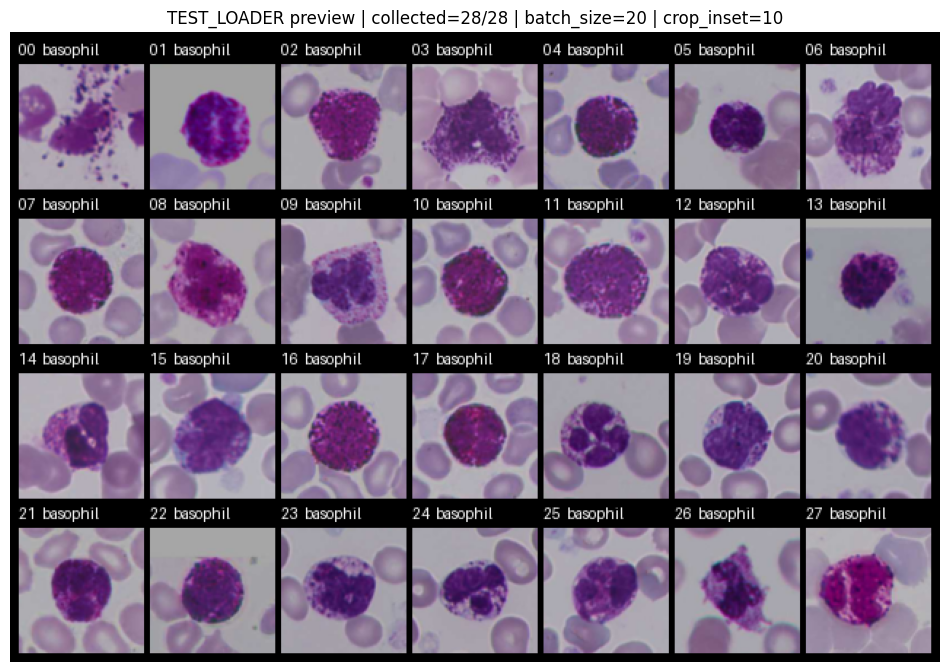

In [7]:
# <<Cell>>
# Optional cell. Skip if broken.
# ------------------------------------------
# Visual: preview a grid from TEST_LOADER (robust when batch_size < grid cells)
# - Pulls across multiple batches until the grid is full (or loader is exhausted).
# - If we still don't have enough samples, fills remaining cells with placeholders.
# ------------------------------------------

def _show_loader_preview_grid(
    *,
    loader: DataLoader,
    class_names: List[str],
    column_count: int = 7,
    row_count: int = 4,
    thumbnail_size: int = 86,
    panel_padding: int = 4,
    outer_padding: int = 6,
    label_height: int = 16,
) -> None:
    font = ImageFont.load_default()

    cell_width = int(thumbnail_size)
    cell_height = int(label_height) + int(thumbnail_size)

    canvas_width = int(column_count) * cell_width + (int(column_count) - 1) * int(panel_padding) + 2 * int(outer_padding)
    canvas_height = int(row_count) * cell_height + (int(row_count) - 1) * int(panel_padding) + 2 * int(outer_padding)

    canvas = Image.new("RGB", (canvas_width, canvas_height), (0, 0, 0))
    draw = ImageDraw.Draw(canvas)

    target_count = int(column_count) * int(row_count)

    collected_images: List[torch.Tensor] = []
    collected_class_indices: List[int] = []

    for image_batch, class_index_batch in loader:
        for item_index in range(int(image_batch.shape[0])):
            collected_images.append(image_batch[item_index])
            collected_class_indices.append(int(class_index_batch[item_index].item()))
            if len(collected_images) >= target_count:
                break
        if len(collected_images) >= target_count:
            break

    item_limit = min(len(collected_images), target_count)

    for item_index in range(target_count):
        row_index, column_index = divmod(int(item_index), int(column_count))

        x_offset = int(outer_padding) + int(column_index) * (cell_width + int(panel_padding))
        y_offset = int(outer_padding) + int(row_index) * (cell_height + int(panel_padding))

        if item_index < item_limit:
            class_index = int(collected_class_indices[item_index])
            class_name = str(class_names[class_index])

            draw.text(
                (x_offset, y_offset),
                f"{item_index:02d}  {class_name}",
                fill=(255, 255, 255),
                font=font,
            )

            thumbnail = tensor_to_pil(collected_images[item_index]).resize(
                (int(thumbnail_size), int(thumbnail_size)),
                Image.Resampling.BILINEAR,
            )

            canvas.paste(thumbnail, (x_offset, y_offset + int(label_height)))
        else:
            # Placeholder cell
            draw.rectangle(
                [x_offset, y_offset + int(label_height), x_offset + int(thumbnail_size), y_offset + int(label_height) + int(thumbnail_size)],
                outline=(60, 60, 60),
                width=1,
            )
            draw.text(
                (x_offset, y_offset),
                f"{item_index:02d}  (empty)",
                fill=(140, 140, 140),
                font=font,
            )

    plt.figure(figsize=(12, 10))
    plt.title(
        f"TEST_LOADER preview | collected={item_limit}/{target_count} | "
        f"batch_size={getattr(loader, 'batch_size', 'unknown')} | crop_inset={NETWORK_POST_AUGMENTATION_INSET}"
    )
    plt.imshow(canvas)
    plt.axis("off")
    plt.show()


_show_loader_preview_grid(loader=TEST_LOADER, class_names=CLASS_NAMES)

In [8]:
# <<Cell>>
# ------------------------------------------
# Model building blocks (shared)
# ------------------------------------------

class GeneralizedMeanPooling(nn.Module):
    def __init__(self, initial_exponent: float = 3.0, epsilon: float = 1e-6):
        super().__init__()
        self.exponent = nn.Parameter(torch.ones(1) * float(initial_exponent))
        self.epsilon = float(epsilon)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = torch.clamp(x, min=self.epsilon)
        x = x.pow(self.exponent)
        x = F.adaptive_avg_pool2d(x, output_size=1)
        x = x.pow(1.0 / self.exponent)
        return x


class SqueezeExcitationBlock(nn.Module):
    def __init__(self, number_of_channels: int, squeeze_ratio: int):
        super().__init__()
        reduced_channels = max(8, int(number_of_channels) // int(squeeze_ratio))

        self.global_average_pool = nn.AdaptiveAvgPool2d(1)
        self.reduce = nn.Conv2d(int(number_of_channels), int(reduced_channels), kernel_size=1)
        self.expand = nn.Conv2d(int(reduced_channels), int(number_of_channels), kernel_size=1)
        self.activation = nn.SiLU(inplace=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        gating = self.global_average_pool(x)
        gating = self.reduce(gating)
        gating = self.activation(gating)
        gating = self.expand(gating)
        gating = torch.sigmoid(gating)
        return x * gating


class DepthwiseSeparableBottleneckBlock(nn.Module):
    def __init__(
        self,
        input_channels: int,
        output_channels: int,
        stride: int,
        group_normalization_groups: int,
        squeeze_ratio: int,
    ):
        super().__init__()

        if int(stride) != 1:
            raise ValueError(
                "DepthwiseSeparableBottleneckBlock requires stride == 1 "
                f"(got stride={stride}). Use DepthwiseSeparableProjectionBottleneckBlock for downsampling."
            )
        if int(input_channels) != int(output_channels):
            raise ValueError(
                "DepthwiseSeparableBottleneckBlock requires input_channels == output_channels "
                f"(got {input_channels} vs {output_channels}). Use DepthwiseSeparableProjectionBottleneckBlock for channel changes."
            )

        self.activation = nn.SiLU(inplace=False)

        self.depthwise_convolution = nn.Conv2d(
            int(input_channels),
            int(input_channels),
            kernel_size=3,
            stride=1,
            padding=1,
            groups=int(input_channels),
            bias=False,
        )
        self.depthwise_normalization = nn.GroupNorm(
            num_groups=int(group_normalization_groups),
            num_channels=int(input_channels),
        )

        self.pointwise_convolution = nn.Conv2d(
            int(input_channels),
            int(output_channels),
            kernel_size=1,
            bias=False,
        )
        self.pointwise_normalization = nn.GroupNorm(
            num_groups=int(group_normalization_groups),
            num_channels=int(output_channels),
        )

        self.squeeze_excitation = SqueezeExcitationBlock(
            number_of_channels=int(output_channels),
            squeeze_ratio=int(squeeze_ratio),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        identity = x

        y = self.depthwise_convolution(x)
        y = self.depthwise_normalization(y)
        y = self.activation(y)

        y = self.pointwise_convolution(y)
        y = self.pointwise_normalization(y)
        y = self.activation(y)

        y = self.squeeze_excitation(y)
        return y + identity


class DepthwiseSeparableProjectionBottleneckBlock(nn.Module):
    def __init__(
        self,
        input_channels: int,
        output_channels: int,
        stride: int,
        group_normalization_groups: int,
        squeeze_ratio: int,
    ):
        super().__init__()

        self.activation = nn.SiLU(inplace=False)

        self.depthwise_convolution = nn.Conv2d(
            int(input_channels),
            int(input_channels),
            kernel_size=3,
            stride=int(stride),
            padding=1,
            groups=int(input_channels),
            bias=False,
        )
        self.depthwise_normalization = nn.GroupNorm(
            num_groups=int(group_normalization_groups),
            num_channels=int(input_channels),
        )

        self.pointwise_convolution = nn.Conv2d(
            int(input_channels),
            int(output_channels),
            kernel_size=1,
            bias=False,
        )
        self.pointwise_normalization = nn.GroupNorm(
            num_groups=int(group_normalization_groups),
            num_channels=int(output_channels),
        )

        self.squeeze_excitation = SqueezeExcitationBlock(
            number_of_channels=int(output_channels),
            squeeze_ratio=int(squeeze_ratio),
        )

        self.projection_skip = nn.Sequential(
            nn.Conv2d(
                int(input_channels),
                int(output_channels),
                kernel_size=1,
                stride=int(stride),
                bias=False,
            ),
            nn.GroupNorm(
                num_groups=int(group_normalization_groups),
                num_channels=int(output_channels),
            ),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        identity = self.projection_skip(x)

        y = self.depthwise_convolution(x)
        y = self.depthwise_normalization(y)
        y = self.activation(y)

        y = self.pointwise_convolution(y)
        y = self.pointwise_normalization(y)
        y = self.activation(y)

        y = self.squeeze_excitation(y)
        return y + identity


print("🧱 Blocks assembled ✅")
print("   🧬 GeneralizedMeanPooling | 🍋 SqueezeExcitationBlock | 🧵 DepthwiseSeparable*BottleneckBlock")


🧱 Blocks assembled ✅
   🧬 GeneralizedMeanPooling | 🍋 SqueezeExcitationBlock | 🧵 DepthwiseSeparable*BottleneckBlock


In [9]:
# <<Cell>>
# ------------------------------------------
# Iguana: fusion head components
# ------------------------------------------

class DualPoolingProjection(nn.Module):
    def __init__(
        self,
        input_channels: int,
        embedding_dimension: int,
        initial_pooling_exponent: float,
    ):
        super().__init__()

        self.generalized_mean_pooling = GeneralizedMeanPooling(
            initial_exponent=float(initial_pooling_exponent)
        )
        self.average_pooling = nn.AdaptiveAvgPool2d(1)

        self.projection = nn.Sequential(
            nn.Flatten(1),
            nn.Linear(int(input_channels) * 2, int(embedding_dimension)),
            nn.SiLU(inplace=False),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        generalized_mean = self.generalized_mean_pooling(x)
        average = self.average_pooling(x)
        stacked = torch.cat([generalized_mean, average], dim=1)  # [N, 2C, 1, 1]
        return self.projection(stacked)


class AuxiliaryKnowledgeBranch(nn.Module):
    def __init__(
        self,
        input_channels: int,
        embedding_dimension: int,
        initial_pooling_exponent: float,
        dropout_probability: float,
    ):
        super().__init__()

        self.pooling = GeneralizedMeanPooling(initial_exponent=float(initial_pooling_exponent))

        self.projection = nn.Sequential(
            nn.Flatten(1),
            nn.Linear(int(input_channels), int(embedding_dimension)),
            nn.SiLU(inplace=False),
            nn.Dropout(p=float(dropout_probability)),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.pooling(x)
        return self.projection(x)


class GatedFeatureFusionClassifier(nn.Module):
    def __init__(
        self,
        embedding_dimension: int,
        number_of_classes: int,
        dropout_probability: float,
    ):
        super().__init__()

        self.gating_network = nn.Sequential(
            nn.Linear(int(embedding_dimension) * 2, int(embedding_dimension)),
            nn.SiLU(inplace=False),
            nn.Linear(int(embedding_dimension), int(embedding_dimension)),
            nn.Sigmoid(),
        )

        self.classifier = nn.Sequential(
            nn.Linear(int(embedding_dimension), int(embedding_dimension // 2)),
            nn.SiLU(inplace=False),
            nn.Dropout(p=float(dropout_probability)),
            nn.Linear(int(embedding_dimension // 2), int(number_of_classes)),
        )

    def forward(self, main_embedding: torch.Tensor, auxiliary_embedding: torch.Tensor) -> torch.Tensor:
        gating_values = self.gating_network(torch.cat([main_embedding, auxiliary_embedding], dim=1))
        fused_embedding = (gating_values * main_embedding) + ((1.0 - gating_values) * auxiliary_embedding)
        return self.classifier(fused_embedding)


print("🦎 Iguana fusion parts ready ✅")
print("   🧲 DualPoolingProjection | 🧠 AuxiliaryKnowledgeBranch | 🪬 GatedFeatureFusionClassifier")


🦎 Iguana fusion parts ready ✅
   🧲 DualPoolingProjection | 🧠 AuxiliaryKnowledgeBranch | 🪬 GatedFeatureFusionClassifier


In [10]:
# <<Cell>>
# ------------------------------------------
# Iguana64 + Falcon64 (do not rename)
# ------------------------------------------

class Iguana64(nn.Module):
    def __init__(
        self,
        number_of_classes: int,
        dropout_probability: float = 0.25,
        group_normalization_groups: int = 8,
        initial_pooling_exponent: float = 3.0,
        squeeze_ratio: int = 32,
        stem_channels: int = 64,
        stage_two_channels: int = 128,
        stage_three_channels: int = 256,
        stage_four_channels: int = 512,
        embedding_dimension: int = 128,
    ):
        super().__init__()

        activation = nn.SiLU(inplace=False)

        self.stem = nn.Sequential(
            nn.Conv2d(3, int(stem_channels), kernel_size=3, stride=1, padding=1, bias=False),
            nn.GroupNorm(num_groups=int(group_normalization_groups), num_channels=int(stem_channels)),
            activation,
        )

        self.stage_two = nn.Sequential(
            DepthwiseSeparableProjectionBottleneckBlock(
                input_channels=int(stem_channels),
                output_channels=int(stage_two_channels),
                stride=2,
                group_normalization_groups=int(group_normalization_groups),
                squeeze_ratio=int(squeeze_ratio),
            ),
            DepthwiseSeparableBottleneckBlock(
                input_channels=int(stage_two_channels),
                output_channels=int(stage_two_channels),
                stride=1,
                group_normalization_groups=int(group_normalization_groups),
                squeeze_ratio=int(squeeze_ratio),
            ),
        )

        self.stage_three = nn.Sequential(
            DepthwiseSeparableProjectionBottleneckBlock(
                input_channels=int(stage_two_channels),
                output_channels=int(stage_three_channels),
                stride=2,
                group_normalization_groups=int(group_normalization_groups),
                squeeze_ratio=int(squeeze_ratio),
            ),
            DepthwiseSeparableBottleneckBlock(
                input_channels=int(stage_three_channels),
                output_channels=int(stage_three_channels),
                stride=1,
                group_normalization_groups=int(group_normalization_groups),
                squeeze_ratio=int(squeeze_ratio),
            ),
        )

        self.stage_four = nn.Sequential(
            DepthwiseSeparableProjectionBottleneckBlock(
                input_channels=int(stage_three_channels),
                output_channels=int(stage_four_channels),
                stride=2,
                group_normalization_groups=int(group_normalization_groups),
                squeeze_ratio=int(squeeze_ratio),
            ),
            DepthwiseSeparableBottleneckBlock(
                input_channels=int(stage_four_channels),
                output_channels=int(stage_four_channels),
                stride=1,
                group_normalization_groups=int(group_normalization_groups),
                squeeze_ratio=int(squeeze_ratio),
            ),
        )

        self.main_dual_pooling_projection = DualPoolingProjection(
            input_channels=int(stage_four_channels),
            embedding_dimension=int(embedding_dimension),
            initial_pooling_exponent=float(initial_pooling_exponent),
        )

        self.auxiliary_branch = AuxiliaryKnowledgeBranch(
            input_channels=int(stage_three_channels),
            embedding_dimension=int(embedding_dimension),
            initial_pooling_exponent=float(initial_pooling_exponent),
            dropout_probability=float(dropout_probability),
        )

        self.fusion_classifier = GatedFeatureFusionClassifier(
            embedding_dimension=int(embedding_dimension),
            number_of_classes=int(number_of_classes),
            dropout_probability=float(dropout_probability),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.stem(x)
        stage_two_features = self.stage_two(x)
        stage_three_features = self.stage_three(stage_two_features)
        stage_four_features = self.stage_four(stage_three_features)
        main_embedding = self.main_dual_pooling_projection(stage_four_features)
        auxiliary_embedding = self.auxiliary_branch(stage_three_features)
        return self.fusion_classifier(main_embedding, auxiliary_embedding)


class Falcon64(nn.Module):
    def __init__(
        self,
        number_of_classes: int,
        dropout_probability: float = 0.25,
        group_normalization_groups: int = 8,
        initial_pooling_exponent: float = 3.0,
        squeeze_ratio: int = 32,
        stem_channels: int = 64,
        stage_two_channels: int = 128,
        stage_three_channels: int = 256,
        stage_four_channels: int = 512,
        head_hidden_dimension: int = 64,
    ):
        super().__init__()

        activation = nn.SiLU(inplace=False)

        self.stem = nn.Sequential(
            nn.Conv2d(3, int(stem_channels), kernel_size=3, stride=1, padding=1, bias=False),
            nn.GroupNorm(num_groups=int(group_normalization_groups), num_channels=int(stem_channels)),
            activation,
        )

        self.stage_two = nn.Sequential(
            DepthwiseSeparableProjectionBottleneckBlock(
                input_channels=int(stem_channels),
                output_channels=int(stage_two_channels),
                stride=2,
                group_normalization_groups=int(group_normalization_groups),
                squeeze_ratio=int(squeeze_ratio),
            ),
            DepthwiseSeparableBottleneckBlock(
                input_channels=int(stage_two_channels),
                output_channels=int(stage_two_channels),
                stride=1,
                group_normalization_groups=int(group_normalization_groups),
                squeeze_ratio=int(squeeze_ratio),
            ),
        )

        self.stage_three = nn.Sequential(
            DepthwiseSeparableProjectionBottleneckBlock(
                input_channels=int(stage_two_channels),
                output_channels=int(stage_three_channels),
                stride=2,
                group_normalization_groups=int(group_normalization_groups),
                squeeze_ratio=int(squeeze_ratio),
            ),
            DepthwiseSeparableBottleneckBlock(
                input_channels=int(stage_three_channels),
                output_channels=int(stage_three_channels),
                stride=1,
                group_normalization_groups=int(group_normalization_groups),
                squeeze_ratio=int(squeeze_ratio),
            ),
        )

        self.stage_four = nn.Sequential(
            DepthwiseSeparableProjectionBottleneckBlock(
                input_channels=int(stage_three_channels),
                output_channels=int(stage_four_channels),
                stride=2,
                group_normalization_groups=int(group_normalization_groups),
                squeeze_ratio=int(squeeze_ratio),
            ),
            DepthwiseSeparableBottleneckBlock(
                input_channels=int(stage_four_channels),
                output_channels=int(stage_four_channels),
                stride=1,
                group_normalization_groups=int(group_normalization_groups),
                squeeze_ratio=int(squeeze_ratio),
            ),
        )

        self.pooling = GeneralizedMeanPooling(initial_exponent=float(initial_pooling_exponent))

        self.classifier = nn.Sequential(
            nn.Flatten(1),
            nn.Linear(int(stage_four_channels), int(head_hidden_dimension)),
            nn.SiLU(inplace=False),
            nn.Dropout(p=float(dropout_probability)),
            nn.Linear(int(head_hidden_dimension), int(number_of_classes)),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.stem(x)
        x = self.stage_two(x)
        x = self.stage_three(x)
        x = self.stage_four(x)
        x = self.pooling(x)
        logits = self.classifier(x)
        return logits


print("🦎 Iguana64 ready ✅  | 🐦 Falcon64 ready ✅")


🦎 Iguana64 ready ✅  | 🐦 Falcon64 ready ✅


In [11]:
# <<Cell>>
# ------------------------------------------
# Winner constants + instantiate/load ensemble
# ------------------------------------------

@dataclass(frozen=True)
class ModelConfiguration:
    architecture_name: str
    member_name: str
    config_id: str
    group_normalization_groups: int
    dropout_probability: float
    embedding_dimension: int
    learning_rate: float
    weight_decay: float
    weights_filename: str


FALCON_GOLD = ModelConfiguration("falcon64", "falcon_gold",   "469de351", 32, 0.2500,  96, 0.0007000000, 0.0000750000, "falcon_gold.pt")
FALCON_SILVER = ModelConfiguration("falcon64", "falcon_silver","3077c92e", 16, 0.1500,  96, 0.0003500000, 0.0001500000, "falcon_silver.pt")
FALCON_BRONZE = ModelConfiguration("falcon64", "falcon_bronze","dceceec4", 32, 0.3000,  96, 0.0007000000, 0.0000750000, "falcon_bronze.pt")

IGUANA_GOLD = ModelConfiguration("iguana64", "iguana_gold",   "fe646604", 16, 0.2000, 256, 0.0003500000, 0.0001500000, "iguana_gold.pt")
IGUANA_SILVER = ModelConfiguration("iguana64", "iguana_silver","3cc9cba7",  4, 0.2000, 128, 0.0005250000, 0.0001875000, "iguana_silver.pt")
IGUANA_BRONZE = ModelConfiguration("iguana64", "iguana_bronze","cb57cdd2", 16, 0.2000, 256, 0.0005250000, 0.0000750000, "iguana_bronze.pt")

ENSEMBLE_MEMBERS: List[ModelConfiguration] = [
    FALCON_GOLD,
    FALCON_SILVER,
    FALCON_BRONZE,
    IGUANA_GOLD,
    IGUANA_SILVER,
    IGUANA_BRONZE,
]

print("🧩 Ensemble members (6) ✅")
for member in ENSEMBLE_MEMBERS:
    print(f"  - {member.member_name:13s} | {member.architecture_name:7s} | weights={member.weights_filename}")


def instantiate_model_from_configuration(member: ModelConfiguration) -> nn.Module:
    if member.architecture_name == "falcon64":
        return Falcon64(
            number_of_classes=int(NUM_CLASSES),
            dropout_probability=float(member.dropout_probability),
            group_normalization_groups=int(member.group_normalization_groups),
            initial_pooling_exponent=3.0,
            squeeze_ratio=int(SQUEEZE_RATIO),
            stem_channels=64,
            stage_two_channels=128,
            stage_three_channels=256,
            stage_four_channels=512,
            head_hidden_dimension=int(member.embedding_dimension),
        )
    if member.architecture_name == "iguana64":
        return Iguana64(
            number_of_classes=int(NUM_CLASSES),
            dropout_probability=float(member.dropout_probability),
            group_normalization_groups=int(member.group_normalization_groups),
            initial_pooling_exponent=3.0,
            squeeze_ratio=int(SQUEEZE_RATIO),
            stem_channels=64,
            stage_two_channels=128,
            stage_three_channels=256,
            stage_four_channels=512,
            embedding_dimension=int(member.embedding_dimension),
        )
    raise ValueError(f"Unknown architecture_name: {member.architecture_name}")


def load_state_dict_strict(*, model: nn.Module, checkpoint_path: Path, device: torch.device) -> nn.Module:
    checkpoint = torch.load(str(checkpoint_path), map_location=device)

    # Most common formats we might see
    if isinstance(checkpoint, dict):
        if "model_state_dict" in checkpoint and isinstance(checkpoint["model_state_dict"], dict):
            state_dict = checkpoint["model_state_dict"]
        elif "state_dict" in checkpoint and isinstance(checkpoint["state_dict"], dict):
            state_dict = checkpoint["state_dict"]
        else:
            # Sometimes people save the state dict under other keys,
            # but if this dict "looks like" a state_dict (all tensor values), accept it.
            looks_like_state_dict = all(isinstance(value, torch.Tensor) for value in checkpoint.values())
            if looks_like_state_dict:
                state_dict = checkpoint
            else:
                raise RuntimeError(
                    "Checkpoint dict does not contain 'model_state_dict' or 'state_dict', "
                    "and does not look like a raw state_dict.\n"
                    f"Keys: {sorted(list(checkpoint.keys()))}"
                )
    else:
        # Raw state_dict case
        state_dict = checkpoint

    # Strip DataParallel prefix if needed
    if any(str(key).startswith("module.") for key in state_dict.keys()):
        state_dict = {str(key).replace("module.", "", 1): value for key, value in state_dict.items()}

    model.load_state_dict(state_dict, strict=True)
    model.to(device)
    model.eval()
    return model


device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print("🖥️ device:", device)

MEMBER_MODELS: Dict[str, nn.Module] = {}
for member in ENSEMBLE_MEMBERS:
    checkpoint_path = MODEL_WEIGHTS_ROOT / member.weights_filename
    if not checkpoint_path.exists() or not is_model_file(checkpoint_path):
        raise FileNotFoundError(f"Missing model checkpoint: {checkpoint_path}")

    model = instantiate_model_from_configuration(member)
    model = load_state_dict_strict(model=model, checkpoint_path=checkpoint_path, device=device)
    MEMBER_MODELS[member.member_name] = model

print("🟢 All models loaded.")

🧩 Ensemble members (6) ✅
  - falcon_gold   | falcon64 | weights=falcon_gold.pt
  - falcon_silver | falcon64 | weights=falcon_silver.pt
  - falcon_bronze | falcon64 | weights=falcon_bronze.pt
  - iguana_gold   | iguana64 | weights=iguana_gold.pt
  - iguana_silver | iguana64 | weights=iguana_silver.pt
  - iguana_bronze | iguana64 | weights=iguana_bronze.pt
🖥️ device: cuda
🟢 All models loaded.


In [28]:
# <<Cell>>
# ------------------------------------------
# Helpers for "single image" ensemble predictions + quality grading + rendering
# ------------------------------------------

from dataclasses import dataclass

@dataclass(frozen=True)
class EnsembleCaseSelection:
    class_name: str
    class_index: int
    image_path: Path


def _load_preprocessed_image_tensor(
    *,
    image_path: Path,
    network_size: int,
    crop_inset: int,
) -> torch.Tensor:
    with Image.open(image_path) as image_handle:
        image = image_handle.convert("RGB")

    image = crop_inset_resize(image, inset=int(crop_inset), size=int(network_size))

    image_array = np.asarray(image).astype(np.float32) / 255.0
    image_array = np.transpose(image_array, (2, 0, 1))  # [C,H,W]
    return torch.from_numpy(image_array)


@torch.no_grad()
def run_ensemble_on_single_image(
    *,
    device: torch.device,
    member_models: Dict[str, nn.Module],
    image_tensor: torch.Tensor,  # [C,H,W] in [0,1]
) -> Dict[str, object]:
    """
    Returns per-member top1, per-member probs, ensemble probs, ensemble top1,
    and a few quality metrics.
    """
    # Stable order for display
    member_items = sorted(member_models.items(), key=lambda item: str(item[0]))

    batch = image_tensor.unsqueeze(0).to(device)  # [1,C,H,W]

    per_member_top1_index: Dict[str, int] = {}
    per_member_top1_probability: Dict[str, float] = {}
    per_member_probabilities: Dict[str, np.ndarray] = {}

    probability_sum: Optional[torch.Tensor] = None

    for member_name, model in member_items:
        model.eval()
        logits = model(batch)  # [1,C]
        probabilities = F.softmax(logits, dim=1)  # [1,C]

        probability_sum = probabilities if probability_sum is None else (probability_sum + probabilities)

        probs_cpu = probabilities[0].detach().cpu().numpy().astype(np.float64)  # [C]
        top1_index = int(np.argmax(probs_cpu))
        top1_prob = float(probs_cpu[top1_index])

        per_member_probabilities[str(member_name)] = probs_cpu
        per_member_top1_index[str(member_name)] = int(top1_index)
        per_member_top1_probability[str(member_name)] = float(top1_prob)

    mean_probabilities = (probability_sum / float(len(member_items)))[0]  # [C]
    ensemble_probs = mean_probabilities.detach().cpu().numpy().astype(np.float64)

    ensemble_top1_index = int(np.argmax(ensemble_probs))
    ensemble_top1_probability = float(ensemble_probs[ensemble_top1_index])

    # Agreement: fraction of members matching ensemble top1
    agreement_fraction = float(
        np.mean([1.0 if per_member_top1_index[name] == ensemble_top1_index else 0.0 for name, _ in member_items])
    )

    # Margin: top1 minus top2
    sorted_probs = np.sort(ensemble_probs)[::-1]
    top2_prob = float(sorted_probs[1]) if len(sorted_probs) > 1 else 0.0
    margin = float(ensemble_top1_probability - top2_prob)

    # Entropy (normalized 0..1), lower is more confident
    epsilon = 1e-12
    entropy = float(-np.sum(ensemble_probs * np.log(ensemble_probs + epsilon)))
    max_entropy = float(np.log(float(len(ensemble_probs)) + epsilon))
    normalized_entropy = float(entropy / max_entropy) if max_entropy > 0 else 1.0

    return {
        "per_member_top1_index": per_member_top1_index,
        "per_member_top1_probability": per_member_top1_probability,
        "per_member_probabilities": per_member_probabilities,
        "ensemble_probabilities": ensemble_probs,
        "ensemble_top1_index": ensemble_top1_index,
        "ensemble_top1_probability": ensemble_top1_probability,
        "agreement_fraction": agreement_fraction,
        "margin": margin,
        "normalized_entropy": normalized_entropy,
        "member_names_sorted": [name for name, _ in member_items],
    }


def grade_measurement_quality(
    *,
    ensemble_top1_probability: float,
    agreement_fraction: float,
    margin: float,
    normalized_entropy: float,
) -> Tuple[str, str]:
    """
    Returns (grade_letter, explanation).
    Heuristics tuned for "how much do I trust this prediction?"
    """
    # Convert entropy -> confidence-ish signal
    entropy_confidence = 1.0 - float(normalized_entropy)

    # Composite trust score in [0,1]
    # We intentionally weight agreement + probability heavily.
    trust_score = (
        0.45 * float(ensemble_top1_probability)
        + 0.35 * float(agreement_fraction)
        + 0.15 * float(np.clip(margin * 2.0, 0.0, 1.0))  # margin scaled
        + 0.05 * float(entropy_confidence)
    )
    trust_score = float(np.clip(trust_score, 0.0, 1.0))

    if trust_score >= 0.85:
        grade = "A"
    elif trust_score >= 0.72:
        grade = "B"
    elif trust_score >= 0.58:
        grade = "C"
    elif trust_score >= 0.45:
        grade = "D"
    else:
        grade = "F"

    explanation = (
        f"trust_score={trust_score:.3f} | "
        f"ens_p={ensemble_top1_probability:.3f}, agree={agreement_fraction:.2f}, "
        f"margin={margin:.3f}, entropy_n={normalized_entropy:.3f}"
    )
    return grade, explanation


def render_case(
    *,
    selection: EnsembleCaseSelection,
    device: torch.device,
    member_models: Dict[str, nn.Module],
    network_size: int,
    crop_inset: int,
    class_names: List[str],
    display_size: int = 380,
) -> None:
    true_class_index = int(selection.class_index)
    true_class_name = str(selection.class_name)

    image_tensor = _load_preprocessed_image_tensor(
        image_path=selection.image_path,
        network_size=int(network_size),
        crop_inset=int(crop_inset),
    )

    prediction_info = run_ensemble_on_single_image(
        device=device,
        member_models=member_models,
        image_tensor=image_tensor,
    )

    ensemble_top1_index = int(prediction_info["ensemble_top1_index"])
    ensemble_top1_probability = float(prediction_info["ensemble_top1_probability"])
    ensemble_top1_name = str(class_names[ensemble_top1_index])

    agreement_fraction = float(prediction_info["agreement_fraction"])
    margin = float(prediction_info["margin"])
    normalized_entropy = float(prediction_info["normalized_entropy"])

    grade, grade_explanation = grade_measurement_quality(
        ensemble_top1_probability=ensemble_top1_probability,
        agreement_fraction=agreement_fraction,
        margin=margin,
        normalized_entropy=normalized_entropy,
    )

    # Prepare display image
    display_pil = tensor_to_pil(image_tensor).resize((int(display_size), int(display_size)), Image.Resampling.BILINEAR)

    # Build text lines: per-member predictions
    member_names_sorted: List[str] = list(prediction_info["member_names_sorted"])
    per_member_top1_index: Dict[str, int] = dict(prediction_info["per_member_top1_index"])
    per_member_top1_probability: Dict[str, float] = dict(prediction_info["per_member_top1_probability"])

    lines: List[str] = []
    for member_name in member_names_sorted:
        pred_index = int(per_member_top1_index[member_name])
        pred_name = str(class_names[pred_index])
        pred_prob = float(per_member_top1_probability[member_name])

        correct = (pred_index == true_class_index)
        icon = "✅" if correct else "❌"
        lines.append(f"{icon} {member_name:13s} → {pred_name:28s}  p={pred_prob:.3f}")

    ensemble_correct = (ensemble_top1_index == true_class_index)
    ensemble_icon = "✅" if ensemble_correct else "❌"

    header = (
        f"True: {true_class_name} (index={true_class_index})\n"
        f"Ensemble: {ensemble_icon} {ensemble_top1_name}  p={ensemble_top1_probability:.3f} | "
        f"agree={agreement_fraction:.2f} | margin={margin:.3f} | grade={grade}\n"
        f"{grade_explanation}"
    )

    # Render: image on left, text on right
        # Render: image on left, text on right (larger font, no overlap, wrap, red+white on black)
    # -------------------------

    import textwrap

    def _try_load_monospace_font(point_size: int) -> ImageFont.FreeTypeFont:
        """
        Tries common mono fonts. Falls back to default if truetype unavailable.
        """
        font_candidates = [
            "/usr/share/fonts/truetype/dejavu/DejaVuSansMono.ttf",
            "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf",
            "/System/Library/Fonts/SFNSMono.ttf",               # macOS (sometimes unavailable in Colab)
            "/Library/Fonts/Menlo.ttc",                        # macOS
        ]
        for path in font_candidates:
            try:
                if Path(path).exists():
                    return ImageFont.truetype(path, size=int(point_size))
            except Exception:
                pass
        return ImageFont.load_default()

    def _font_line_height(font: ImageFont.ImageFont) -> int:
        # Robust height: bbox of a tall-ish sample
        left, top, right, bottom = font.getbbox("Ag|Qy")
        return int(bottom - top)

    def _text_pixel_width(text: str, font: ImageFont.ImageFont) -> int:
        left, top, right, bottom = font.getbbox(text)
        return int(right - left)

    def _wrap_to_width(text: str, font: ImageFont.ImageFont, max_width: int) -> List[str]:
        """
        Pixel-aware wrapping. Preserves existing newlines and wraps each paragraph.
        """
        lines_out: List[str] = []
        for paragraph in str(text).split("\n"):
            if paragraph.strip() == "":
                lines_out.append("")
                continue

            words = paragraph.split(" ")
            current = ""
            for word in words:
                candidate = word if current == "" else (current + " " + word)
                if _text_pixel_width(candidate, font) <= max_width:
                    current = candidate
                else:
                    if current:
                        lines_out.append(current)
                    # If a single word is too wide, hard-break it
                    if _text_pixel_width(word, font) <= max_width:
                        current = word
                    else:
                        chunk = ""
                        for ch in word:
                            cand2 = chunk + ch
                            if _text_pixel_width(cand2, font) <= max_width:
                                chunk = cand2
                            else:
                                if chunk:
                                    lines_out.append(chunk)
                                chunk = ch
                        current = chunk
            if current:
                lines_out.append(current)
        return lines_out

    # Fonts (bigger + readable)
    header_font = _try_load_monospace_font(point_size=24)
    body_font = _try_load_monospace_font(point_size=22)

    header_line_height = _font_line_height(header_font)
    body_line_height = _font_line_height(body_font)

    # Colors (requested: red + white on black)
    COLOR_WHITE = (245, 245, 245)
    COLOR_RED = (255, 70, 70)
    COLOR_BLACK = (0, 0, 0)

    # Panel geometry
    text_panel_width = 680
    padding = 18
    line_spacing = 6  # extra pixels between lines (prevents "kissed" lines)

    canvas_width = int(display_size) + padding + text_panel_width + padding
    canvas_height = int(display_size) + 2 * padding  # will be expanded if text needs more

    # Create temporary draw to wrap text based on pixel width
    temp_canvas = Image.new("RGB", (canvas_width, canvas_height), COLOR_BLACK)
    temp_draw = ImageDraw.Draw(temp_canvas)

    max_text_width = int(text_panel_width - 2 * padding)

    # Build wrapped header lines (use header font)
    header_wrapped: List[str] = _wrap_to_width(header, header_font, max_text_width)

    # Build wrapped per-member lines (use body font). Usually these fit, but wrap anyway.
    member_wrapped_lines: List[Tuple[str, Tuple[int, int, int]]] = []
    for member_name in member_names_sorted:
        pred_index = int(per_member_top1_index[member_name])
        pred_name = str(class_names[pred_index])
        pred_prob = float(per_member_top1_probability[member_name])

        correct = (pred_index == true_class_index)
        icon = "✅" if correct else "❌"
        line_text = f"{icon} {member_name:13s} -> {pred_name:28s}  p={pred_prob:.3f}"

        # Color rule: wrong lines are red, correct lines are white (still only red/white overall)
        line_color = COLOR_WHITE if correct else COLOR_RED

        wrapped = _wrap_to_width(line_text, body_font, max_text_width)
        for wrapped_line in wrapped:
            member_wrapped_lines.append((wrapped_line, line_color))

    # Add a small divider line under header
    divider = "-" * 70
    divider_wrapped = _wrap_to_width(divider, body_font, max_text_width)

    # Compute required height
    text_height = 0
    text_height += len(header_wrapped) * (header_line_height + line_spacing)
    text_height += 1 * (body_line_height + line_spacing)  # blank line
    text_height += len(divider_wrapped) * (body_line_height + line_spacing)
    text_height += 1 * (body_line_height + line_spacing)  # blank line
    text_height += len(member_wrapped_lines) * (body_line_height + line_spacing)
    text_panel_height = padding * 2 + text_height

    canvas_height = int(max(int(display_size) + 2 * padding, text_panel_height))

    # Final canvas
    canvas = Image.new("RGB", (int(canvas_width), int(canvas_height)), COLOR_BLACK)
    draw = ImageDraw.Draw(canvas)

    # Paste image
    canvas.paste(display_pil, (padding, padding))

    x_text = int(display_size) + padding * 2
    y_text = padding

    # Header (mostly white; make the grade line red if grade is poor)
    for line in header_wrapped:
        # If the header line contains "grade=" and it's not A/B, tint red for emphasis
        line_color = COLOR_WHITE
        if "grade=" in line:
            if ("grade=C" in line) or ("grade=D" in line) or ("grade=F" in line):
                line_color = COLOR_RED
        draw.text((x_text, y_text), line, fill=line_color, font=header_font)
        y_text += header_line_height + line_spacing

    # Spacer
    y_text += body_line_height // 2

    # Divider
    for line in divider_wrapped:
        draw.text((x_text, y_text), line, fill=COLOR_WHITE, font=body_font)
        y_text += body_line_height + line_spacing

    # Spacer
    y_text += body_line_height // 2

    # Member lines
    for line_text, line_color in member_wrapped_lines:
        draw.text((x_text, y_text), line_text, fill=line_color, font=body_font)
        y_text += body_line_height + line_spacing

    plt.figure(figsize=(14, 6))
    plt.imshow(canvas)
    plt.axis("off")
    plt.title(f"Case | class={true_class_name} | file={selection.image_path.name}")
    plt.show()

🧪 Selected 5 cases (fixed seed):
  [0] class=normoblast                    file=normoblast_1262_lab_c0_d0.jpg
  [1] class=neutrophil_segmented          file=neutrophil_segmented_0247_lab_c0_d0.jpg
  [2] class=lymphocyte                    file=lymphocyte_0948_lab_c0_d0.jpg
  [3] class=metamyelocyte                 file=metamyelocyte_0128_lab_c0_d0.jpg
  [4] class=monocyte                      file=monocyte_0509_lab_c0_d0.jpg


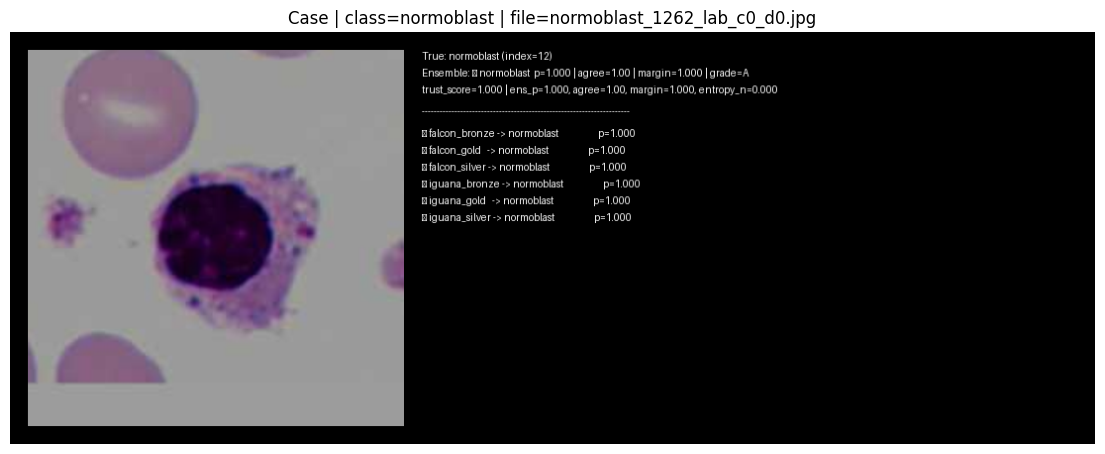

In [30]:
# <<Cell>>
# Optional cell. Skip if broken.

_random_seed = 1516
_class_count_to_pick = 5

random_generator = np.random.RandomState(int(_random_seed))

# Pick 5 distinct classes (by index)
picked_class_indices = random_generator.choice(np.arange(NUM_CLASSES), size=int(_class_count_to_pick), replace=False).tolist()
picked_class_indices = [int(x) for x in picked_class_indices]

CASE_SELECTIONS: List[EnsembleCaseSelection] = []

for class_index in picked_class_indices:
    class_name = str(CLASS_NAMES[int(class_index)])
    class_root = TEST_ROOT / class_name

    image_paths = sorted([p for p in class_root.rglob("*") if is_image_file(p)])
    if not image_paths:
        raise RuntimeError(f"No images found for class: {class_name} under {class_root}")

    chosen_index = int(random_generator.randint(0, len(image_paths)))
    chosen_path = image_paths[chosen_index]

    CASE_SELECTIONS.append(
        EnsembleCaseSelection(
            class_name=class_name,
            class_index=int(class_index),
            image_path=chosen_path,
        )
    )

print("🧪 Selected 5 cases (fixed seed):")
for i, sel in enumerate(CASE_SELECTIONS):
    print(f"  [{i}] class={sel.class_name:28s}  file={sel.image_path.name}")

# Render case #0
render_case(
    selection=CASE_SELECTIONS[0],
    device=device,
    member_models=MEMBER_MODELS,
    network_size=NETWORK_SIZE,
    crop_inset=NETWORK_POST_AUGMENTATION_INSET,
    class_names=CLASS_NAMES,
    display_size=380,
)

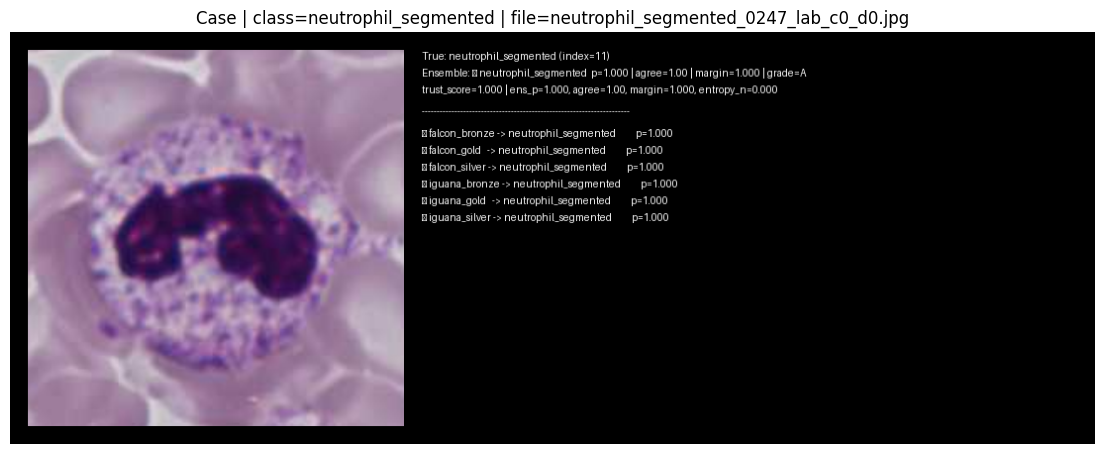

In [31]:
# <<Cell>>
# Optional cell. Skip if broken.
# ------------------------------------------
# Render case #1
# ------------------------------------------

render_case(
    selection=CASE_SELECTIONS[1],
    device=device,
    member_models=MEMBER_MODELS,
    network_size=NETWORK_SIZE,
    crop_inset=NETWORK_POST_AUGMENTATION_INSET,
    class_names=CLASS_NAMES,
    display_size=380,
)

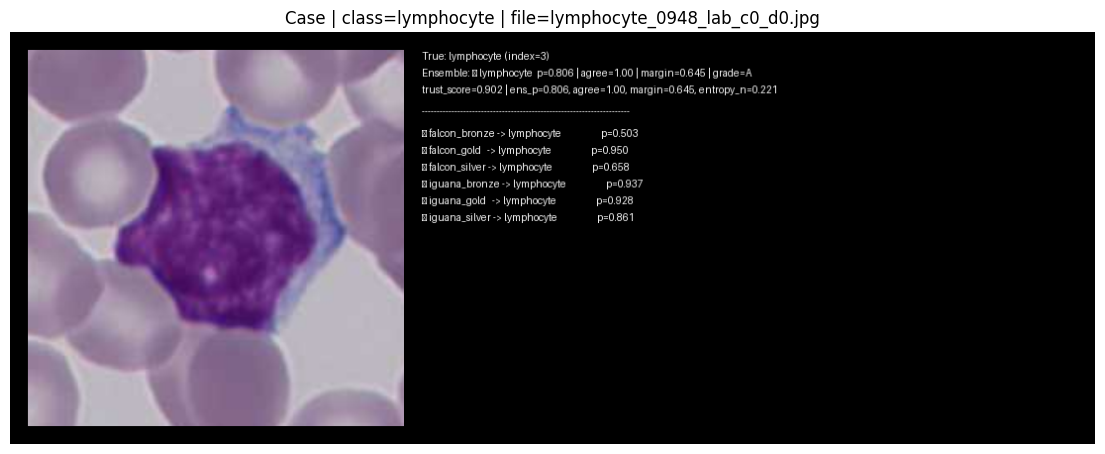

In [32]:
# <<Cell>>
# Optional cell. Skip if broken.
# ------------------------------------------
# Render case #2
# ------------------------------------------

render_case(
    selection=CASE_SELECTIONS[2],
    device=device,
    member_models=MEMBER_MODELS,
    network_size=NETWORK_SIZE,
    crop_inset=NETWORK_POST_AUGMENTATION_INSET,
    class_names=CLASS_NAMES,
    display_size=380,
)

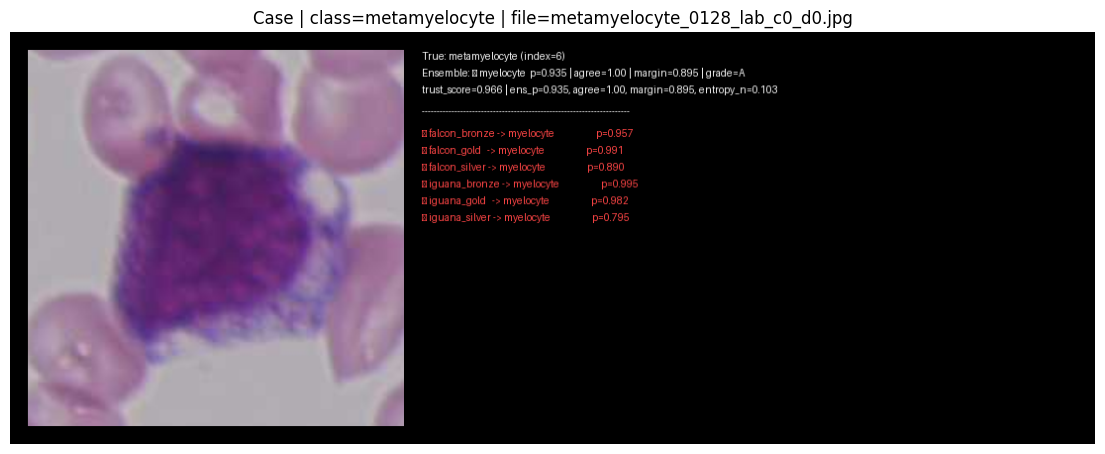

In [33]:
# <<Cell>>
# Optional cell. Skip if broken.
# ------------------------------------------
# Render case #3
# ------------------------------------------

render_case(
    selection=CASE_SELECTIONS[3],
    device=device,
    member_models=MEMBER_MODELS,
    network_size=NETWORK_SIZE,
    crop_inset=NETWORK_POST_AUGMENTATION_INSET,
    class_names=CLASS_NAMES,
    display_size=380,
)

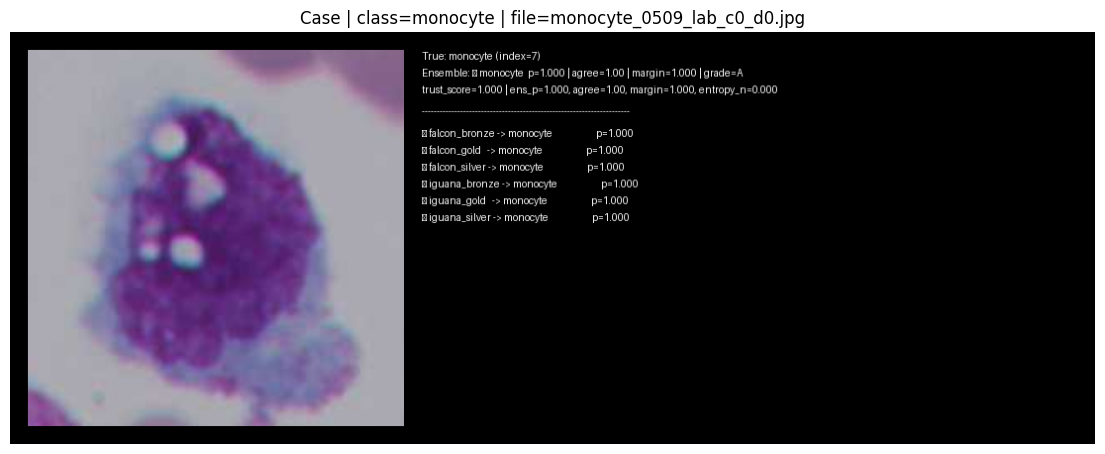

In [34]:
# <<Cell>>
# Optional cell. Skip if broken.
# ------------------------------------------
# Render case #4
# ------------------------------------------

render_case(
    selection=CASE_SELECTIONS[4],
    device=device,
    member_models=MEMBER_MODELS,
    network_size=NETWORK_SIZE,
    crop_inset=NETWORK_POST_AUGMENTATION_INSET,
    class_names=CLASS_NAMES,
    display_size=380,
)

✅ Ensemble test accuracy: 0.9316 (93.16%)
Samples: 3452


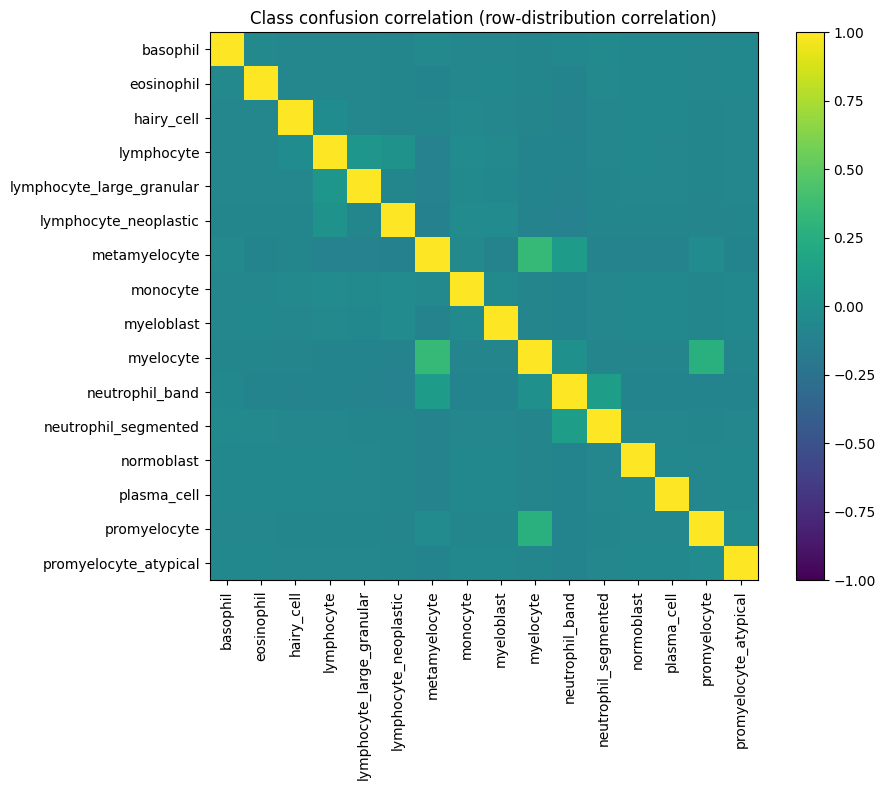

In [35]:
# <<Cell>>
# ------------------------------------------
# Ensemble evaluation on test set + confusion correlation heat map
# ------------------------------------------

@torch.no_grad()
def run_ensemble_predictions(
    *,
    device: torch.device,
    member_models: Dict[str, nn.Module],
    loader: DataLoader,
) -> Tuple[np.ndarray, np.ndarray]:
    true_indices: List[int] = []
    predicted_indices: List[int] = []

    for model in member_models.values():
        model.eval()

    for image_batch, class_index_batch in loader:
        image_batch = image_batch.to(device)
        class_index_batch = class_index_batch.to(device)

        probability_sum: Optional[torch.Tensor] = None
        for model in member_models.values():
            logits = model(image_batch)
            probabilities = F.softmax(logits, dim=1)
            probability_sum = probabilities if probability_sum is None else (probability_sum + probabilities)

        mean_probabilities = probability_sum / float(len(member_models))
        predicted_class_index_batch = torch.argmax(mean_probabilities, dim=1)

        true_indices.extend(class_index_batch.detach().cpu().numpy().tolist())
        predicted_indices.extend(predicted_class_index_batch.detach().cpu().numpy().tolist())

    return np.asarray(true_indices, dtype=np.int64), np.asarray(predicted_indices, dtype=np.int64)


def compute_confusion_matrix(*, true_indices: np.ndarray, predicted_indices: np.ndarray, num_classes: int) -> np.ndarray:
    matrix = np.zeros((num_classes, num_classes), dtype=np.int64)
    for true_value, predicted_value in zip(true_indices.tolist(), predicted_indices.tolist()):
        matrix[int(true_value), int(predicted_value)] += 1
    return matrix


true_indices, predicted_indices = run_ensemble_predictions(
    device=device,
    member_models=MEMBER_MODELS,
    loader=TEST_LOADER,
)

accuracy = float((true_indices == predicted_indices).mean()) if len(true_indices) else 0.0
print(f"✅ Ensemble test accuracy: {accuracy:.4f} ({accuracy * 100.0:.2f}%)")
print("Samples:", len(true_indices))

confusion_matrix = compute_confusion_matrix(
    true_indices=true_indices,
    predicted_indices=predicted_indices,
    num_classes=NUM_CLASSES,
)

# Normalize rows to distributions and correlate those distributions across classes
row_sums = np.maximum(confusion_matrix.sum(axis=1, keepdims=True).astype(np.float32), 1.0)
confusion_row_distribution = confusion_matrix.astype(np.float32) / row_sums
correlation_matrix = np.corrcoef(confusion_row_distribution)
correlation_matrix = np.nan_to_num(correlation_matrix, nan=0.0, posinf=0.0, neginf=0.0)

plt.figure(figsize=(10, 8))
plt.title("Class confusion correlation (row-distribution correlation)")
plt.imshow(correlation_matrix, vmin=-1.0, vmax=1.0)
plt.colorbar()
plt.xticks(ticks=np.arange(NUM_CLASSES), labels=CLASS_NAMES, rotation=90)
plt.yticks(ticks=np.arange(NUM_CLASSES), labels=CLASS_NAMES)
plt.tight_layout()
plt.show()

📏 Calibration stats:
   ECE (15 bins): 0.0130
   Brier score:   0.0465
   N:             3452


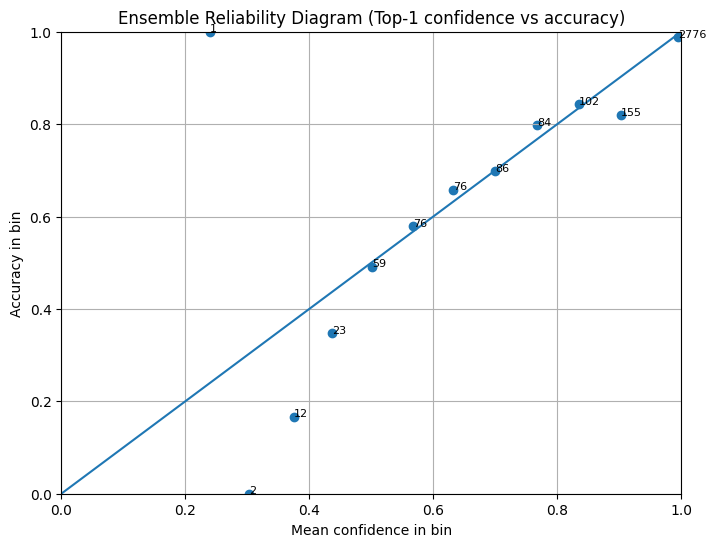

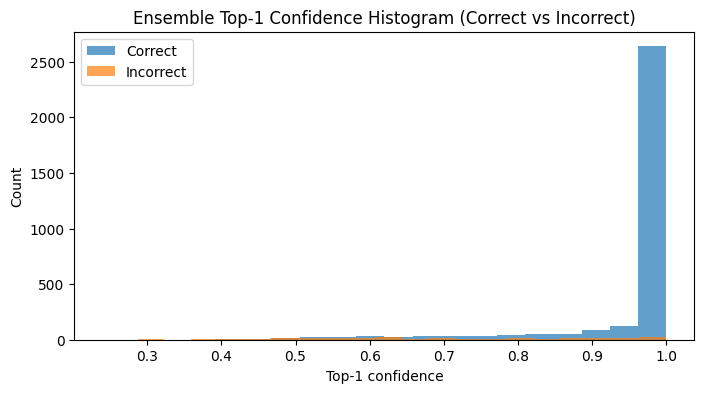

In [19]:
# <<Cell>>
# ------------------------------------------
# Overboard stats graph: Ensemble calibration (reliability diagram) + ECE + Brier score
# ------------------------------------------

@torch.no_grad()
def collect_ensemble_confidence_and_correctness(
    *,
    device: torch.device,
    member_models: Dict[str, nn.Module],
    loader: DataLoader,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Returns:
      confidences: [N] ensemble max probability
      correct_flags: [N] 1.0 if correct else 0.0
    """
    member_items = sorted(member_models.items(), key=lambda item: str(item[0]))
    confidences: List[float] = []
    correct_flags: List[float] = []

    for image_batch, class_index_batch in loader:
        image_batch = image_batch.to(device)
        class_index_batch = class_index_batch.to(device)

        probability_sum: Optional[torch.Tensor] = None
        for _, model in member_items:
            model.eval()
            logits = model(image_batch)
            probabilities = F.softmax(logits, dim=1)
            probability_sum = probabilities if probability_sum is None else (probability_sum + probabilities)

        mean_probabilities = probability_sum / float(len(member_items))  # [N,C]
        predicted_indices = torch.argmax(mean_probabilities, dim=1)      # [N]
        max_probabilities = torch.max(mean_probabilities, dim=1).values  # [N]

        correct = (predicted_indices == class_index_batch).to(torch.float32)

        confidences.extend(max_probabilities.detach().cpu().numpy().astype(np.float64).tolist())
        correct_flags.extend(correct.detach().cpu().numpy().astype(np.float64).tolist())

    return np.asarray(confidences, dtype=np.float64), np.asarray(correct_flags, dtype=np.float64)


def compute_calibration_bins(
    *,
    confidences: np.ndarray,
    correct_flags: np.ndarray,
    bin_count: int = 15,
) -> Dict[str, np.ndarray]:
    """
    Equal-width bins in [0,1].
    Returns bin centers, bin accuracies, bin mean confidence, bin counts, ece.
    """
    bin_edges = np.linspace(0.0, 1.0, int(bin_count) + 1, dtype=np.float64)
    bin_indices = np.digitize(confidences, bin_edges, right=True) - 1
    bin_indices = np.clip(bin_indices, 0, int(bin_count) - 1)

    bin_counts = np.zeros((bin_count,), dtype=np.int64)
    bin_accuracy = np.zeros((bin_count,), dtype=np.float64)
    bin_confidence = np.zeros((bin_count,), dtype=np.float64)

    for b in range(int(bin_count)):
        mask = (bin_indices == b)
        count = int(mask.sum())
        bin_counts[b] = count
        if count > 0:
            bin_accuracy[b] = float(correct_flags[mask].mean())
            bin_confidence[b] = float(confidences[mask].mean())
        else:
            bin_accuracy[b] = np.nan
            bin_confidence[b] = np.nan

    total_count = max(1, int(len(confidences)))
    ece = 0.0
    for b in range(int(bin_count)):
        if bin_counts[b] > 0:
            weight = float(bin_counts[b]) / float(total_count)
            ece += weight * float(abs(bin_accuracy[b] - bin_confidence[b]))

    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    return {
        "bin_centers": bin_centers,
        "bin_accuracy": bin_accuracy,
        "bin_confidence": bin_confidence,
        "bin_counts": bin_counts.astype(np.float64),
        "ece": np.asarray([ece], dtype=np.float64),
        "bin_edges": bin_edges,
    }


def compute_brier_score(*, confidences: np.ndarray, correct_flags: np.ndarray) -> float:
    # For top-1 confidence: (p - y)^2 averaged
    return float(np.mean((confidences - correct_flags) ** 2))


confidences, correct_flags = collect_ensemble_confidence_and_correctness(
    device=device,
    member_models=MEMBER_MODELS,
    loader=TEST_LOADER,
)

calibration = compute_calibration_bins(confidences=confidences, correct_flags=correct_flags, bin_count=15)
ece = float(calibration["ece"][0])
brier = compute_brier_score(confidences=confidences, correct_flags=correct_flags)

print(f"📏 Calibration stats:")
print(f"   ECE (15 bins): {ece:.4f}")
print(f"   Brier score:   {brier:.4f}")
print(f"   N:             {len(confidences)}")

# Reliability diagram
plt.figure(figsize=(8, 6))
plt.title("Ensemble Reliability Diagram (Top-1 confidence vs accuracy)")

# Perfect calibration line
plt.plot([0, 1], [0, 1])

# Bin points (skip empty bins)
bin_conf = calibration["bin_confidence"]
bin_acc = calibration["bin_accuracy"]
mask = ~np.isnan(bin_conf) & ~np.isnan(bin_acc)

plt.scatter(bin_conf[mask], bin_acc[mask])
for x, y, c in zip(bin_conf[mask], bin_acc[mask], calibration["bin_counts"][mask]):
    plt.text(float(x), float(y), f"{int(c)}", fontsize=8)

plt.xlim(0.0, 1.0)
plt.ylim(0.0, 1.0)
plt.xlabel("Mean confidence in bin")
plt.ylabel("Accuracy in bin")
plt.grid(True)
plt.show()

# Confidence histogram (correct vs incorrect)
plt.figure(figsize=(8, 4))
plt.title("Ensemble Top-1 Confidence Histogram (Correct vs Incorrect)")
correct_conf = confidences[correct_flags >= 0.5]
incorrect_conf = confidences[correct_flags < 0.5]

plt.hist(correct_conf, bins=20, alpha=0.7, label="Correct")
plt.hist(incorrect_conf, bins=20, alpha=0.7, label="Incorrect")
plt.xlabel("Top-1 confidence")
plt.ylabel("Count")
plt.legend()
plt.show()